In [1]:
import sys
import os
from pathlib import Path
# Go up until you find the project root
while not (Path.cwd() / ".gitignore").exists() and Path.cwd() != Path("/"):
    os.chdir("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
results_df = pd.read_csv('output/integration_analysis/summary.csv')

In [ ]:
auc_cols    = ["AUC_PO_only", "AUC_PA_only", "AUC_PO_plus_PA",
               "AUC_PO_bplus_PA_ens", "AUC_PO_plus_PA_smooth"]

In [14]:
# mean by region
results_df.groupby(['region', 'split_type'])[auc_cols].mean().mean()

AUC_PO_only              0.684567
AUC_PA_only              0.632527
AUC_PO_plus_PA           0.683293
AUC_PO_plus_PA_ens       0.684747
AUC_PO_plus_PA_smooth    0.687967
dtype: float64

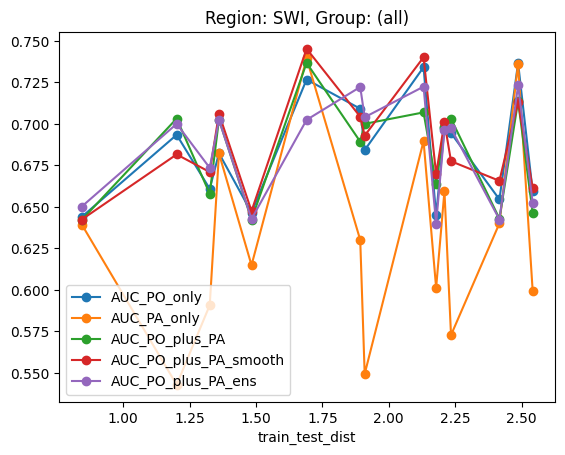

In [8]:
regions = results_df['region'].unique()
for region in regions:
    df_region = results_df[results_df['region'] == region]
    groups = df_region['group'].unique()
    for group in groups:
        df_region_group = df_region[df_region['group'] == group]
        # sort by train_test_dist
        df_region_group = df_region_group.sort_values(by='train_test_dist', ascending=False)
        # plot
        df_region_group.plot(x='train_test_dist', 
                             y=["AUC_PO_only", "AUC_PA_only", "AUC_PO_plus_PA"
                                , "AUC_PO_plus_PA_smooth", "AUC_PO_plus_PA_ens"
                                ], 
                             marker='o', title=f'Region: {region}, Group: {group}')


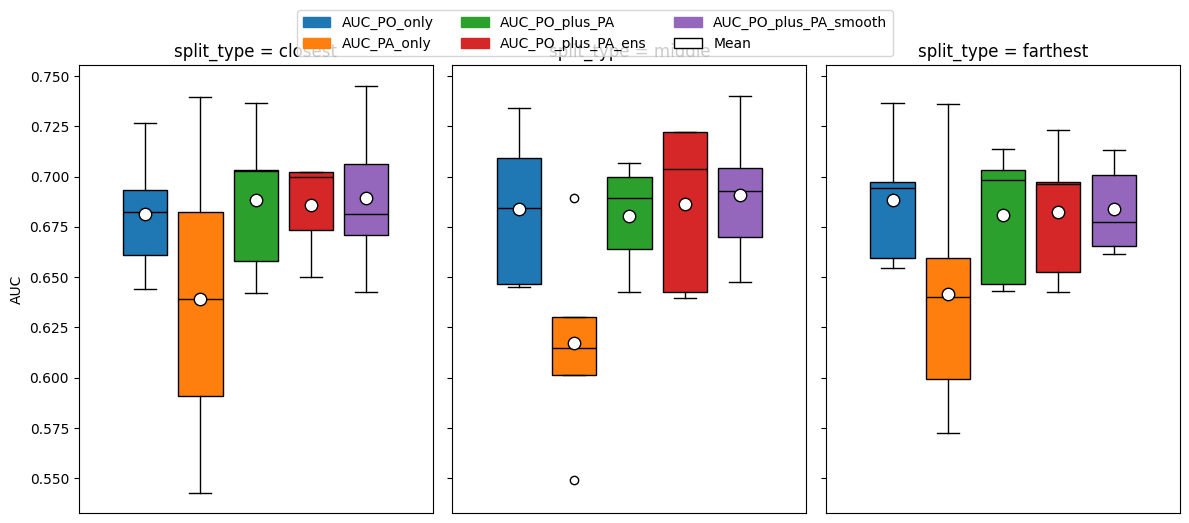

In [13]:
import matplotlib.patches as mpatches
import numpy as np

auc_cols    = ["AUC_PO_only", "AUC_PA_only", "AUC_PO_plus_PA",
               "AUC_PO_plus_PA_ens", "AUC_PO_plus_PA_smooth"]
colors      = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]
split_types = ['closest', 'middle', 'farthest']

fig, axes = plt.subplots(
    1, len(split_types),
    figsize=(4 * len(split_types), 5),
    sharey=True
)

if len(split_types) == 1:
    axes = [axes]

n_box = len(auc_cols)
positions = np.linspace(-1, 1, n_box)
width     = 2/n_box  

for ax, split in zip(axes, split_types):
    df_sub = results_df[results_df["split_type"] == split]
    data   = [df_sub[c].dropna().values for c in auc_cols]

    # Boxplot
    bp = ax.boxplot(
        data,
        positions=positions,
        widths=width,
        patch_artist=True,
        medianprops=dict(color="black")
    )

    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)

    # === Mean Markers Only ===
    means = [np.mean(d) for d in data]
    ax.scatter(
        positions,
        means,
        s=80,
        marker='o',
        edgecolor='black',
        facecolor='white',
        zorder=3,
        label="Mean"
    )

    ax.set_title(f"split_type = {split}")
    ax.set_xlim(-1.6, 1.6)
    ax.set_xticks([])

axes[0].set_ylabel("AUC")

# Legend
handles = [mpatches.Patch(color=c, label=l) for c, l in zip(colors, auc_cols)]
handles.append(
    mpatches.Patch(facecolor="white", edgecolor="black", label="Mean (○)")
)

fig.legend(handles, [*auc_cols, "Mean"], loc="upper center",
           ncol=3, bbox_to_anchor=(0.5, 1.05))

plt.tight_layout()
plt.show()


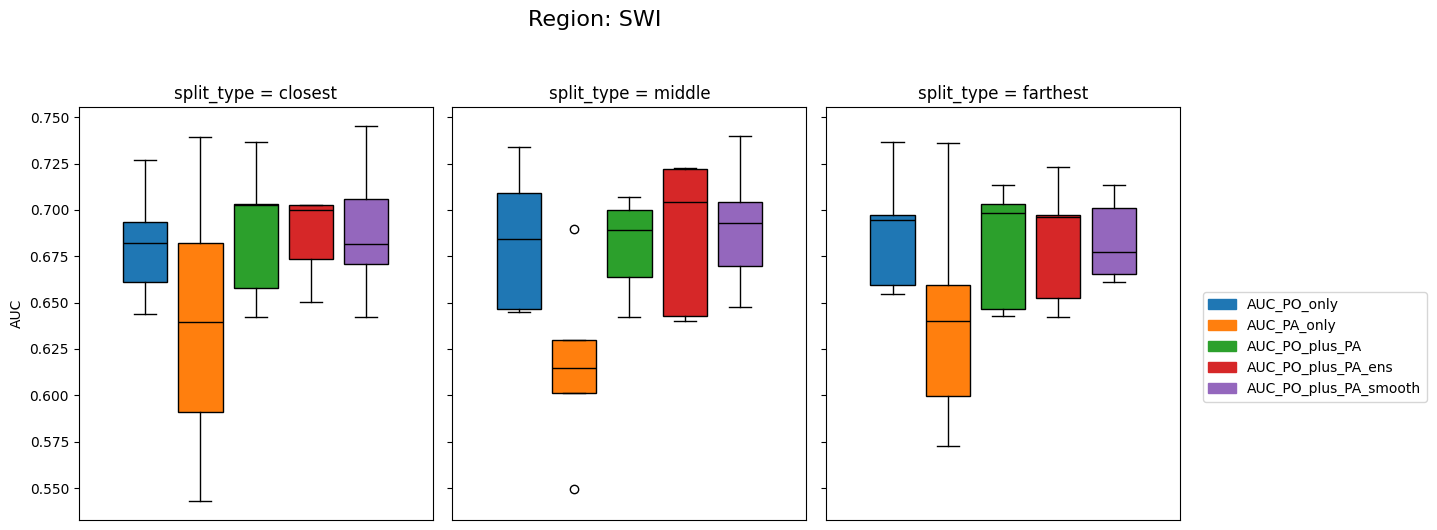

In [6]:
unique_regions = results_df['region'].unique()
for region in unique_regions:
    df_region = results_df[results_df['region'] == region]

    auc_cols    = ["AUC_PO_only", "AUC_PA_only", "AUC_PO_plus_PA",
                "AUC_PO_plus_PA_ens", "AUC_PO_plus_PA_smooth"]
    colors      = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]
    split_types = ['closest', 'middle', 'farthest']

    fig, axes = plt.subplots(
        1, len(split_types),
        figsize=(4 * len(split_types), 5),
        sharey=True
    )
    if len(split_types) == 1:
        axes = [axes]

    # positions = np.array([-1, 0, 1])   # centers
    n_box = len(auc_cols)
    positions = np.linspace(-1, 1, n_box)  # spread out
    # width     = 1.0                    # full width -> boxes just touch
    width     =  2/n_box            # narrower boxes

    for ax, split in zip(axes, split_types):
        df_sub = df_region[df_region["split_type"] == split]
        data   = [df_sub[c].dropna().values for c in auc_cols]

        bp = ax.boxplot(
            data,
            positions=positions,
            widths=width,
            patch_artist=True,
            medianprops=dict(color="black")

        )

        for patch, color in zip(bp["boxes"], colors):
            patch.set_facecolor(color)

        ax.set_title(f"split_type = {split}")
        ax.set_xlim(-1.6, 1.6)
        ax.set_xticks([])

    axes[0].set_ylabel("AUC")

    # add title
    fig.suptitle(f"Region: {region}", y=1.05, fontsize=16)

    handles = [mpatches.Patch(color=c, label=l) for c, l in zip(colors, auc_cols)]
    fig.legend(handles, auc_cols, loc="upper center", ncol=1, bbox_to_anchor=(1.1, .5))

    plt.tight_layout()
    plt.show()


<Axes: xlabel='train_test_dist'>

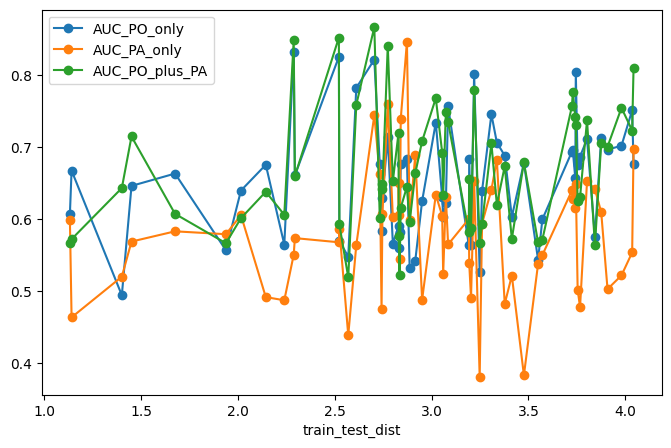

In [46]:
results_df.sort_values(by = 'train_test_dist').plot(
    x="train_test_dist",
    y=["AUC_PO_only", "AUC_PA_only", "AUC_PO_plus_PA"],
    kind="line",
    marker="o",
    figsize=(8,5)
)


<Axes: xlabel='train_test_dist'>

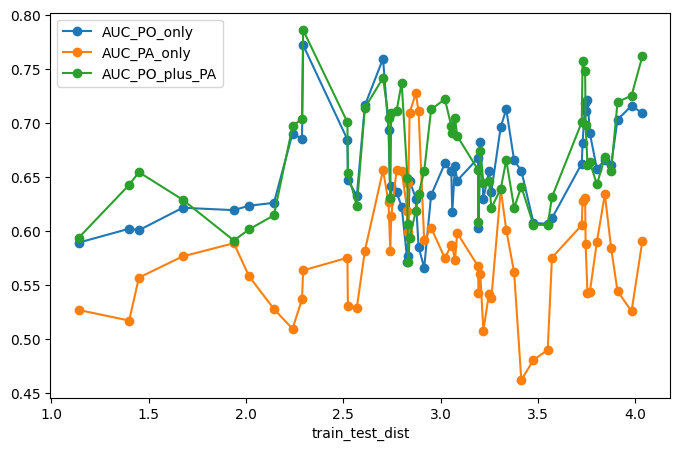

In [47]:
df = results_df.sort_values('train_test_dist').copy()

# Apply rolling mean smoothing (window=3 is typical; adjust as needed)
df[['AUC_PO_only', 'AUC_PA_only', 'AUC_PO_plus_PA']] = (
    df[['AUC_PO_only', 'AUC_PA_only', 'AUC_PO_plus_PA']]
      .rolling(window=3, center=True)
      .mean()
)

df.plot(
    x="train_test_dist",
    y=["AUC_PO_only", "AUC_PA_only", "AUC_PO_plus_PA"],
    kind="line",
    marker="o",
    figsize=(8,5)
)


<Axes: xlabel='train_test_dist'>

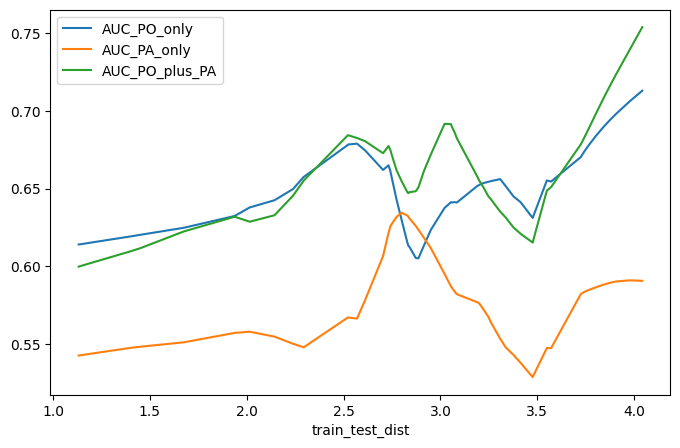

In [48]:
from statsmodels.nonparametric.smoothers_lowess import lowess

df = results_df.sort_values('train_test_dist').copy()

for col in ["AUC_PO_only", "AUC_PA_only", "AUC_PO_plus_PA"]:
    smoothed = lowess(df[col], df['train_test_dist'], frac=0.3)
    df[col] = smoothed[:,1]

df.plot(
    x="train_test_dist",
    y=["AUC_PO_only", "AUC_PA_only", "AUC_PO_plus_PA"],
    kind="line",
    figsize=(8,5)
)
